In [1]:
import pandas as pd

In [4]:
from Utils import *

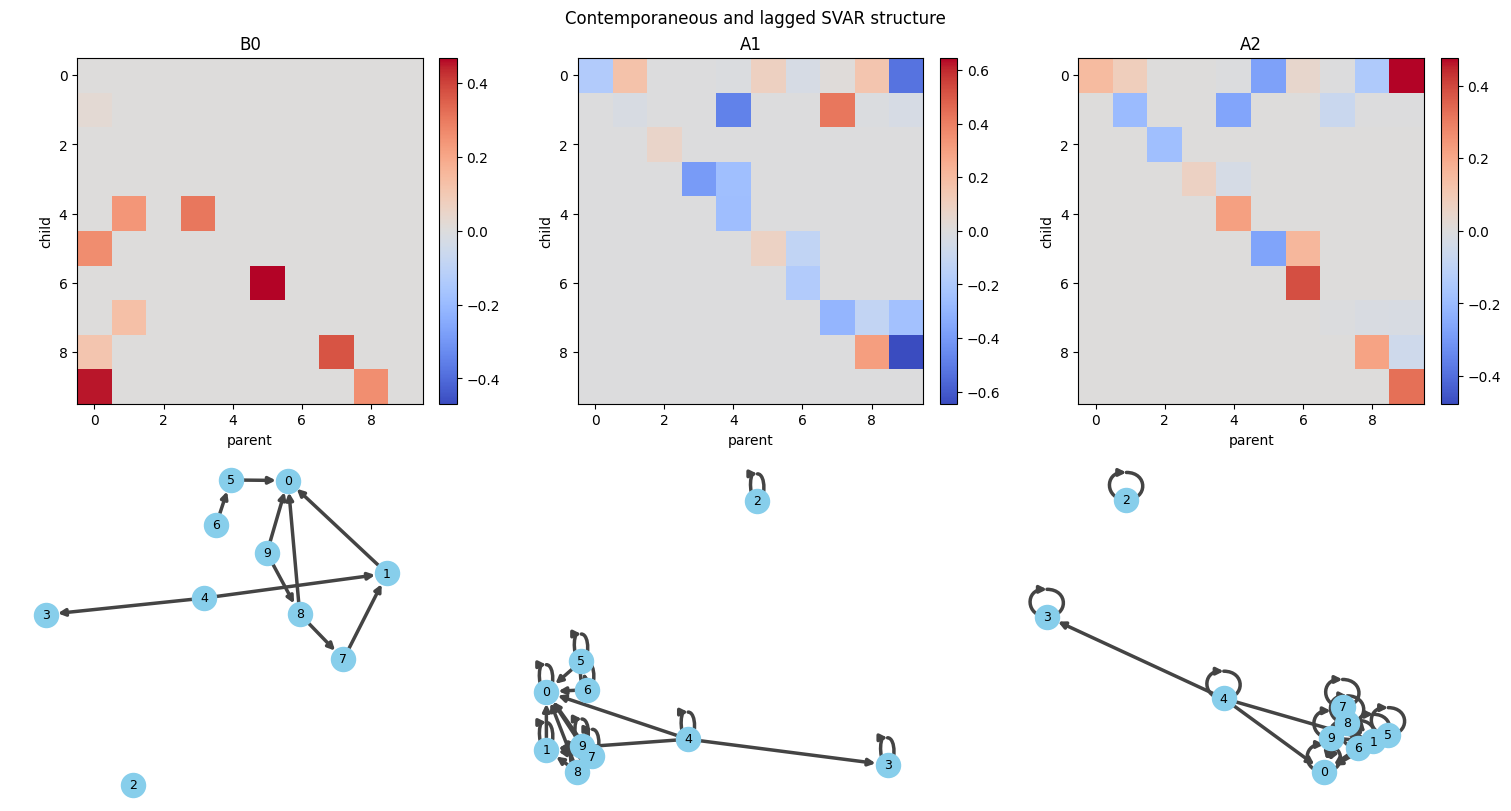

In [3]:
NUM_NODES = 10
DEGREE = 3
GRAPH_TYPE = "er" 
SEED = 42 
from Utils import create_dag, simulate_svar, plot_svar_structure
W_true, dag = create_dag(n_nodes=NUM_NODES, graph_type=GRAPH_TYPE, edges=DEGREE * NUM_NODES // 2)
# a = nx.Digraph(W_true)

res = simulate_svar(
    n_obs=1000,
    n_vars=10,
    lag_order=2,
    structure=dag
)
plot_svar_structure(dag, res['A_lags'], node_order=list(dag.nodes()), seed = SEED)

Generated DAG with 18 edges.
Simulated 500 observations.
Dynotears learned 30 nodes / 230 edges.


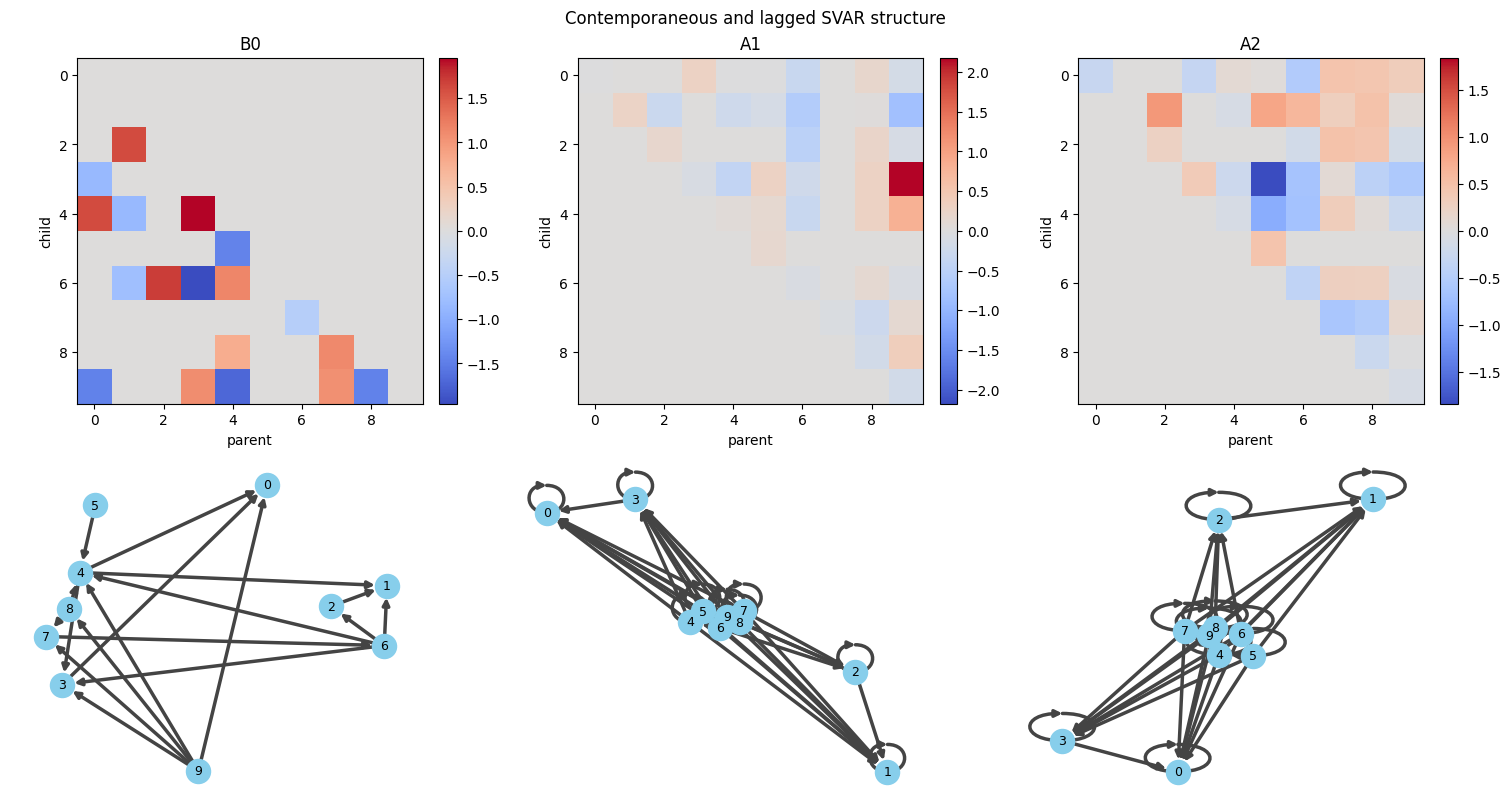

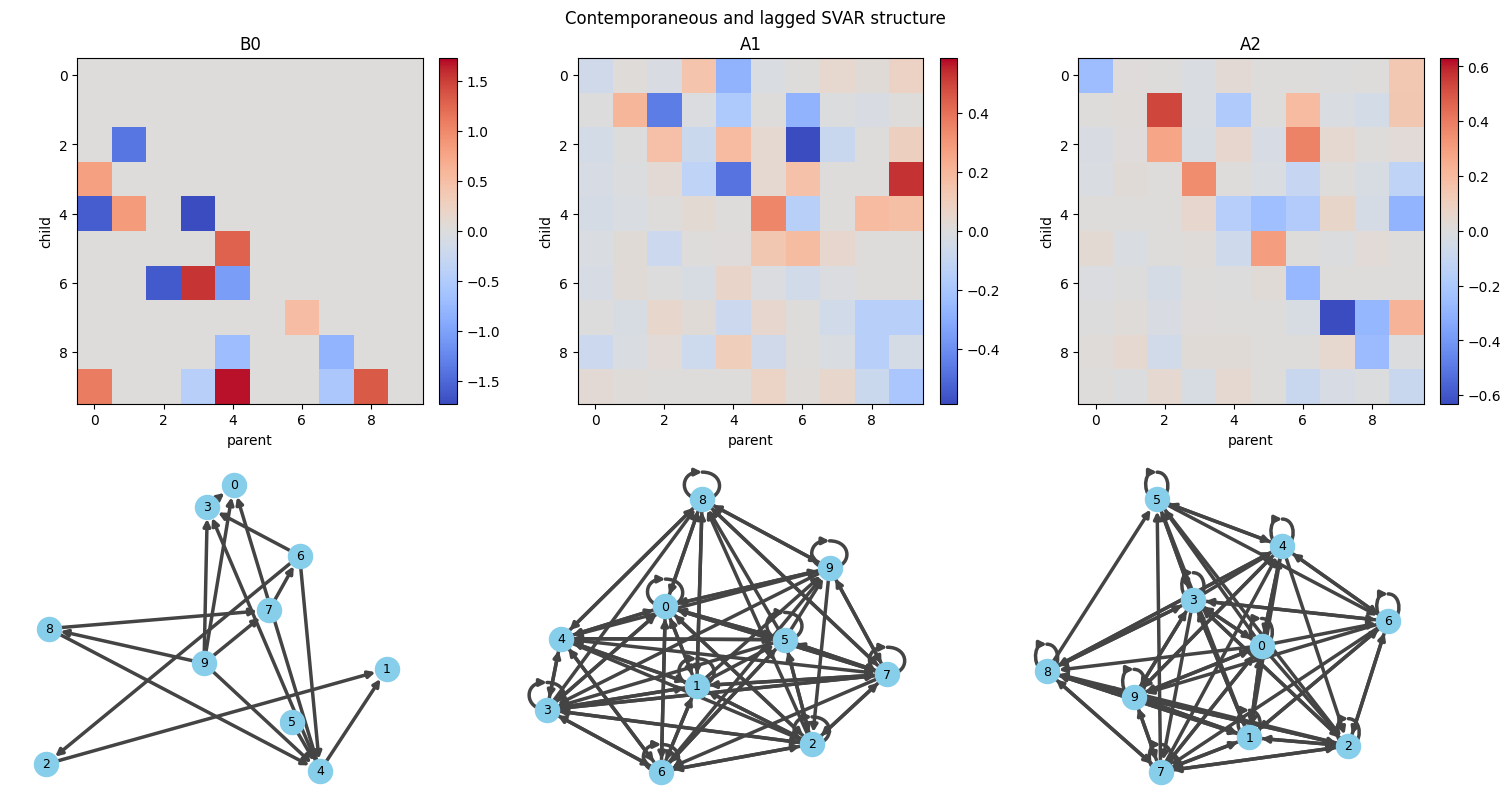

In [9]:
import numpy as np
# import pandas as pd
import networkx as nx
import warnings
warnings.filterwarnings("ignore")
from Utils import create_dag, simulate_svar
from Utils import to_bin, count_accuracy, plot_svar_structure
from dynotears import from_pandas_dynamic



def structure_to_matrices(structure_model, variables, lag_order):
    variables = list(variables)
    n_vars = len(variables)
    name_to_idx = {str(var): idx for idx, var in enumerate(variables)}

    instantaneous = np.zeros((n_vars, n_vars))
    lagged = np.zeros((lag_order, n_vars, n_vars))

    for parent, child, data in structure_model.edges(data=True):
        weight = float(data.get("weight", 0.0))
        parent_var, parent_lag = parent.rsplit("_lag", 1)
        child_var, child_lag = child.rsplit("_lag", 1)

        child_lag = int(child_lag)
        parent_lag = int(parent_lag)
        if child_lag != 0:
            continue  # only look at edges ending in the current slice

        p_idx = name_to_idx[parent_var]
        c_idx = name_to_idx[child_var]

        if parent_lag == 0:
            instantaneous[c_idx, p_idx] = weight
        elif 1 <= parent_lag <= lag_order:
            lagged[parent_lag - 1, c_idx, p_idx] = weight

    return instantaneous, lagged


def run_once():
    # ----- user-chosen settings -----
    n_nodes = 10
    n_edges = 15
    n_obs = 500
    lag_order = 2
    graph_type = "er"  # options: "er", "sf", "sf_t", "sw", "sw_t"
    seed = 42
    lambda_w = 0.1
    lambda_a = 0.01
    # --------------------------------

    rng = np.random.default_rng(seed)

    W_true, dag = create_dag(
        n_nodes=n_nodes,
        graph_type=graph_type,
        edges=n_edges,
        permute=False,
        edge_type="weighted",
        w_range=((-2.0, -0.5), (0.5, 2.0)),
    )
    print(f"Generated DAG with {dag.number_of_edges()} edges.")

    svar = simulate_svar(
        n_obs=n_obs,
        n_vars=n_nodes,
        lag_order=lag_order,
        structure=dag,
        seed=rng.integers(0, 1_000_000),
    )

    columns = list(svar["nodes"])
    data = pd.DataFrame(svar["data"], columns=columns)
    print(f"Simulated {len(data)} observations.")

    sm = from_pandas_dynamic(
        data,
        p=lag_order,
        lambda_w=lambda_w,
        lambda_a=lambda_a,
    )
    print(
        "Dynotears learned "
        f"{sm.number_of_nodes()} nodes / {sm.number_of_edges()} edges."
    )

    B_adj_est, A_adj_est = structure_to_matrices(sm, columns, lag_order)
    B0_est = np.eye(n_nodes) - B_adj_est

    B0_graph = B0_est.T.copy()
    np.fill_diagonal(B0_graph, 0.0)
    B0_graph[np.abs(B0_graph) < 0.3] = 0.0  # clip small-magnitude edges

    # Stack ground-truth and estimated matrices: [B0, A1, A2, …]
    B0_true = svar["B0"]
    A_true = np.stack(svar["A_lags"])
    C_GT = np.concatenate(([B0_true], A_true), axis=0)

    A_est = A_adj_est
    C_est = np.concatenate(([B0_est], A_est), axis=0)

    threshold = 0.5

    def bin_matrix(M):
        return to_bin(M, threshold)

    metrics = {}

    # Contemporaneous slice
    B0_true_bin = bin_matrix(svar["B0"])
    B0_est_bin = bin_matrix(B0_graph)
    shd, tpr, fdr = count_accuracy(B0_true_bin, B0_est_bin)
    metrics["B0"] = {"shd": shd, "tpr": tpr, "fdr": fdr}

    # Lag slices
    for idx in range(lag_order):
        A_true_bin = bin_matrix(svar["A_lags"][idx])
        A_est_bin = bin_matrix(A_adj_est[idx])
        shd, tpr, fdr = count_accuracy(A_true_bin, A_est_bin)
        metrics[f"A{idx + 1}"] = {"shd": shd, "tpr": tpr, "fdr": fdr}

    dag_est = nx.from_numpy_array(B0_graph, create_using=nx.DiGraph)

    return dag, dag_est, svar['A_lags'], A_est, metrics

if __name__ == "__main__":
    dag, dag_est, A_GT, A_est, metrics = run_once()
    plot_svar_structure(dag, A_GT, node_order=list(dag.nodes()), seed = SEED)
    plot_svar_structure(dag_est, A_est, node_order=list(dag_est.nodes()), seed = SEED)
